# LAB TASKS
- Import Required Libraries
- Load Dataset
- Use a dataset Breast Cancer Dataset from sklearn.datasets.
- Exploratory Data Analysis (EDA)
- Display first few rows of the dataset.
- Check for missing values.
- Plot histograms or distribution of features.
- Check class distribution (malignant vs. benign).
- Data Preprocessing
- Split features and labels.
- Standardize features using StandardScaler.
- Train-test split.
- Model Implementation
- Use sklearn.linear_model.LogisticRegression.
- Train the model on the training data.
- Predict on the test data.
- Evaluation
- Accuracy score.
- Confusion matrix.
- Precision, Recall, F1-score

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
print("Target classes:", cancer.target_names)

Target classes: ['malignant' 'benign']


In [2]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
   mean radius  mean texture  mean perimeter  ...  worst symmetry  worst fractal dimension  target
0        17.99         10.38          122.80  ...          0.4601                  0.11890       0
1        20.57         17.77          132.90  ...          0.2750                  0.08902       0
2        19.69         21.25          130.00  ...          0.3613                  0.08758       0
3        11.42         20.38           77.58  ...          0.6638                  0.17300       0
4        20.29         14.34          135.10  ...          0.2364                  0.07678       0

[5 rows x 31 columns]


In [3]:
print("\n--- Missing Values ---")
print(f"Total missing values: {df.isnull().sum().sum()}")


--- Missing Values ---
Total missing values: 0


In [4]:
class_counts = df["target"].value_counts()
class_distribution = pd.DataFrame(
    {
        "Class": [cancer.target_names[i] for i in class_counts.index],
        "Count": class_counts.values,
        "Percentage": (class_counts.values / len(df) * 100).round(2),
    }
)
print("\n--- Class Distribution ---")
print(class_distribution.to_string(index=False))


--- Class Distribution ---
    Class  Count  Percentage
   benign    357       62.74
malignant    212       37.26


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23064\2358726627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="coolwarm")


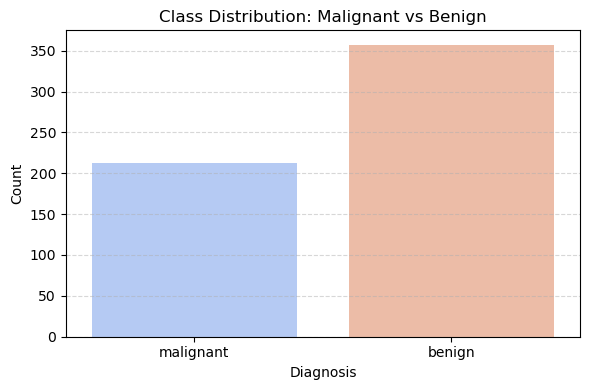

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="coolwarm")
plt.xticks(ticks=[0, 1], labels=cancer.target_names)
plt.title("Class Distribution: Malignant vs Benign")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

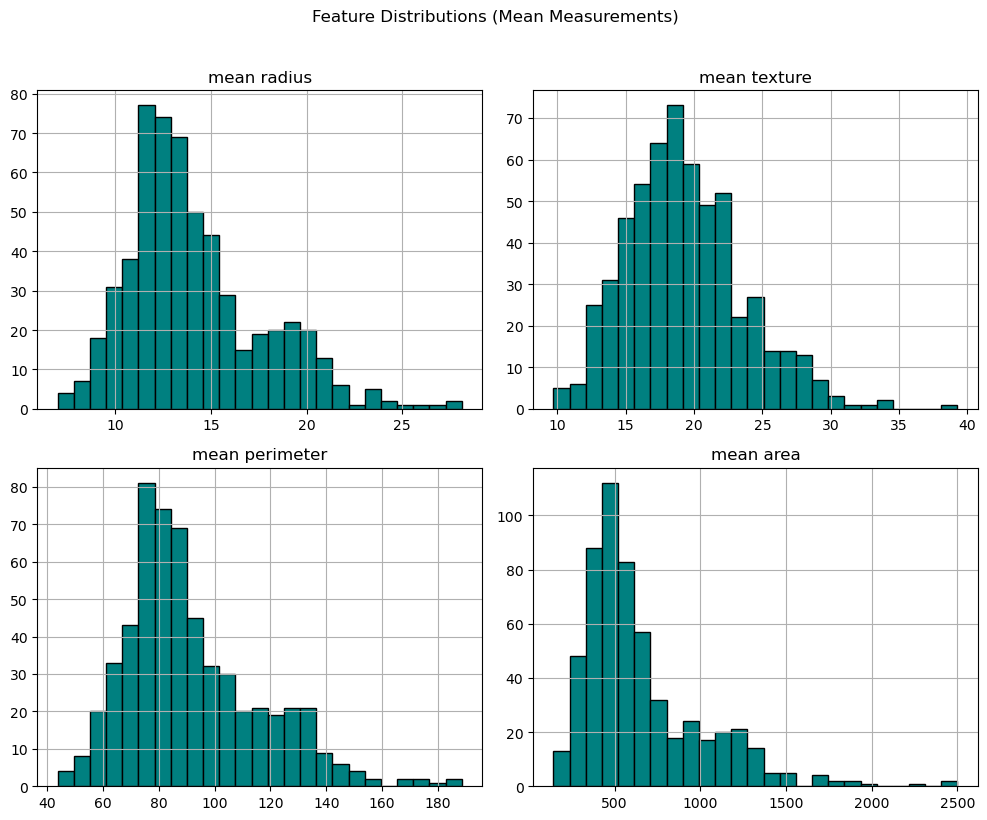

In [6]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
]
df[selected_features].hist(bins=25, figsize=(10, 8), color="teal", edgecolor="k")
plt.suptitle("Feature Distributions (Mean Measurements)", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [9]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Test Set Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


--- Test Set Metrics ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861


In [12]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))


--- Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



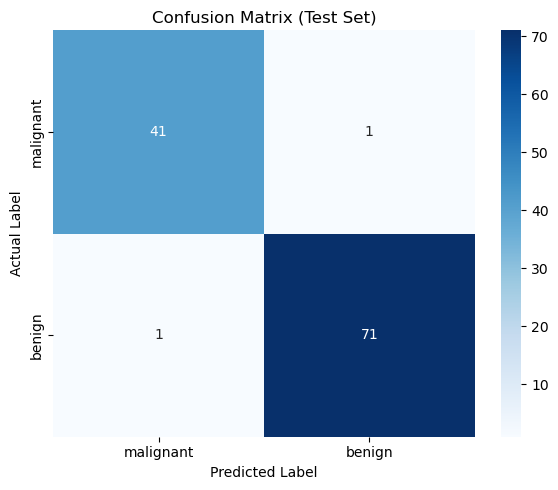

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()